# ProductLens — Clasificador de Imágenes de Productos de Consumo

El presente notebook documenta el desarrollo de un clasificador de imágenes entrenado sobre un subconjunto de productos de consumo. Dado que el dataset original no contaba con etiquetas, se empleó el modelo CLIP para la clasificación automática de imágenes en dos categorías. El entrenamiento se realizó mediante Transfer Learning sobre la arquitectura MobileNetV2.

### Categorías
| Categoría | Carpeta |
|---|---|
| Artículos para el hogar y la cocina | `hogar_cocina` |
| Cuidado personal y belleza | `cuidado_personal` |

### Fases del pipeline
1. Configuración del entorno y descarga del dataset desde Kaggle
2. Clasificación automática de imágenes con CLIP
3. Construcción del dataset balanceado (7.400 imágenes)
4. Entrenamiento — Fase 1: ajuste de cabeza de clasificación
5. Entrenamiento — Fase 2: fine-tuning de últimas 30 capas
6. Evaluación del modelo y guardado

## Verificación de GPU

In [1]:
import tensorflow as tf

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible: {gpus[0].name}')
else:
    print('Sin GPU - ve a Entorno de ejecucion, Cambiar tipo, T4 GPU')

TensorFlow: 2.20.0
✅ GPU disponible: /physical_device:GPU:0


## Paso 1: Configurar Kaggle y descargar dataset

In [2]:
import os, json

KAGGLE_USERNAME = 'Sol'
KAGGLE_KEY      = 'KGAT_ae6797f2b3cad636dfbc3927f4e80007'

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
creds = {'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}
creds_path = os.path.join(kaggle_dir, 'kaggle.json')
with open(creds_path, 'w') as f:
    json.dump(creds, f)
os.chmod(creds_path, 0o600)
print('Credenciales Kaggle configuradas')

✅ Credenciales Kaggle configuradas


In [3]:
!pip install kaggle -q
!kaggle datasets download -d freshersstaff/product-images-dataset --unzip -p /content/raw_dataset
print(' Dataset descargado')

Dataset URL: https://www.kaggle.com/datasets/freshersstaff/product-images-dataset
License(s): CC0-1.0
100% 2.72G/2.72G [00:28<00:00, 101MB/s]

✅ Dataset descargado


In [4]:
import pathlib

raw_path = pathlib.Path('/content/raw_dataset')
all_images = list(raw_path.rglob('*.jpg')) + \
             list(raw_path.rglob('*.jpeg')) + \
             list(raw_path.rglob('*.png')) + \
             list(raw_path.rglob('*.webp'))

print(f'Total imágenes encontradas: {len(all_images):,}')
dirs = sorted(set(p.parent for p in all_images))
print(f'Total carpetas: {len(dirs)}')
print('Primeras 5 carpetas:')
for d in dirs[:5]:
    n = len(list(d.glob('*')))
    print(f'  {d.name}  ({n} archivos)')

Total imágenes encontradas: 398,212
Total carpetas: 256
Primeras 5 carpetas:
  00  (1506 archivos)
  01  (1563 archivos)
  02  (1581 archivos)
  03  (1568 archivos)
  04  (1521 archivos)


## Paso 2: Clasificación automática de imágenes con CLIP

Se emplea el modelo CLIP de OpenAI para asignar etiquetas a cada imagen de forma automática,
comparando cada una contra descripciones textuales de las categorías definidas y seleccionando
la de mayor similitud.

In [5]:
!pip install open-clip-torch -q
print('open-clip instalado')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
✅ open-clip instalado


Se inicializa el modelo CLIP en su variante ViT-B/32 con pesos preentrenados de OpenAI y se asigna
al dispositivo disponible, en este caso GPU T4. Esta variante ofrece un balance adecuado entre
velocidad de inferencia y precisión para tareas de clasificación por similitud semántica.
La descarga de los pesos se realiza una única vez y queda almacenada en caché para ejecuciones posteriores.

In [6]:
import torch
import open_clip
from PIL import Image
import numpy as np
from tqdm import tqdm


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando dispositivo: {device}')

model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model = model.to(device).eval()
tokenizer = open_clip.get_tokenizer('ViT-B-32')
print('Modelo CLIP cargado')

Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Modelo CLIP cargado


Se definen los prompts descriptivos en inglés para cada categoría, siguiendo el formato esperado
por CLIP.

Por cada categoría se generan múltiples descripciones para cubrir la variabilidad visual
de los productos.

Luego se tokenizan y codifican como vectores de características, obteniendo
un vector representativo por categoría mediante promedio, que será usado como referencia en la clasificación.

In [7]:

CATEGORY_PROMPTS = {
    'hogar_cocina': [
        'a photo of a kitchen utensil',
        'a photo of cookware like a pan or pot',
        'a photo of a cup or mug',
        'a photo of a home appliance like a blender',
        'a photo of a pillow or cushion',
        'a photo of dinnerware or tableware',
        'a photo of household items for the kitchen',
        'a photo of a frying pan or saucepan',
    ],
    'cuidado_personal': [
        'a photo of a cosmetic product',
        'a photo of skincare cream or lotion',
        'a photo of shampoo or hair care product',
        'a photo of makeup like lipstick or eyeshadow',
        'a photo of a toothbrush or hairbrush',
        'a photo of personal hygiene product',
        'a photo of beauty product packaging',
        'a photo of perfume or deodorant',
    ],
}


all_prompts = []
prompt_to_cat = []
for cat, prompts in CATEGORY_PROMPTS.items():
    for p in prompts:
        all_prompts.append(p)
        prompt_to_cat.append(cat)

with torch.no_grad():
    text_tokens = tokenizer(all_prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)


cats = list(CATEGORY_PROMPTS.keys())
cat_features = {}
for cat in cats:
    idxs = [i for i, c in enumerate(prompt_to_cat) if c == cat]
    cat_features[cat] = text_features[idxs].mean(dim=0)
    cat_features[cat] = cat_features[cat] / cat_features[cat].norm()

print('Prompts tokenizados')
print(f'Categorías: {cats}')

✅ Prompts tokenizados
Categorías: ['hogar_cocina', 'cuidado_personal']


Se define un Dataset personalizado para procesar las imágenes en lotes y se ejecuta la clasificación
con CLIP sobre la totalidad del dataset.

Cada imagen se compara contra los vectores representativos
de cada categoría y se le asigna la de mayor similitud.

Los resultados, incluyendo categoría asignada
y puntaje de confianza, se almacenan en un archivo CSV para su uso en las siguientes etapas.

In [8]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class ImagePathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img), str(path)
        except Exception:
            return torch.zeros(3, 224, 224), str(path)


BATCH_SIZE =
dataset_clip = ImagePathDataset(all_images, preprocess)
loader = DataLoader(dataset_clip, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

results = []

print(f'Clasificando {len(all_images):,} imágenes con CLIP...')
print(f'Batches: {len(loader)} × {BATCH_SIZE}')

with torch.no_grad():
    for imgs, paths in tqdm(loader, desc='CLIP'):
        imgs = imgs.to(device)
        img_features = model.encode_image(imgs)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)


        scores = {}
        for cat in cats:
            sim = (img_features @ cat_features[cat].unsqueeze(-1)).squeeze(-1)
            scores[cat] = sim.cpu().numpy()

        for i, path in enumerate(paths):
            cat_scores = {cat: float(scores[cat][i]) for cat in cats}
            best_cat = max(cat_scores, key=cat_scores.get)
            best_score = cat_scores[best_cat]
            results.append({
                'path': path,
                'category': best_cat,
                'score': best_score,
                **{f'score_{c}': cat_scores[c] for c in cats}
            })

df = pd.DataFrame(results)
df.to_csv('/content/clip_scores.csv', index=False)
print(f'\n Clasificación completada')
print(df['category'].value_counts())
print(f'Score promedio: {df["score"].mean():.3f}')

Clasificando 398,212 imágenes con CLIP...
Batches: 3112 × 128


CLIP: 100%|██████████| 3112/3112 [26:04<00:00,  1.99it/s]



✅ Clasificación completada
category
hogar_cocina        201116
cuidado_personal    197096
Name: count, dtype: int64
Score promedio: 0.223


*  La clasificación se completó sobre las 398.212 imágenes en aproximadamente 26 minutos.

*  La distribución resultante es prácticamente equilibrada entre ambas categorías, lo cual es favorable
para el entrenamiento.

*  El score promedio de 0.223 es un valor esperado para CLIP en tareas de clasificación
de producto, e indica que el modelo operó con una similitud semántica moderada pero consistente.





##Paso 3: Construir dataset balanceado de 7.400 imágenes

Se definen los tamaños de cada partición del dataset y el umbral mínimo de confianza CLIP aceptable, además se filtran las imágenes que superan dicho umbral para garantizar la calidad de las etiquetas asignadas,
y se visualiza la distribución de scores por categoría para verificar que haya suficientes imágenes
disponibles para cada partición.

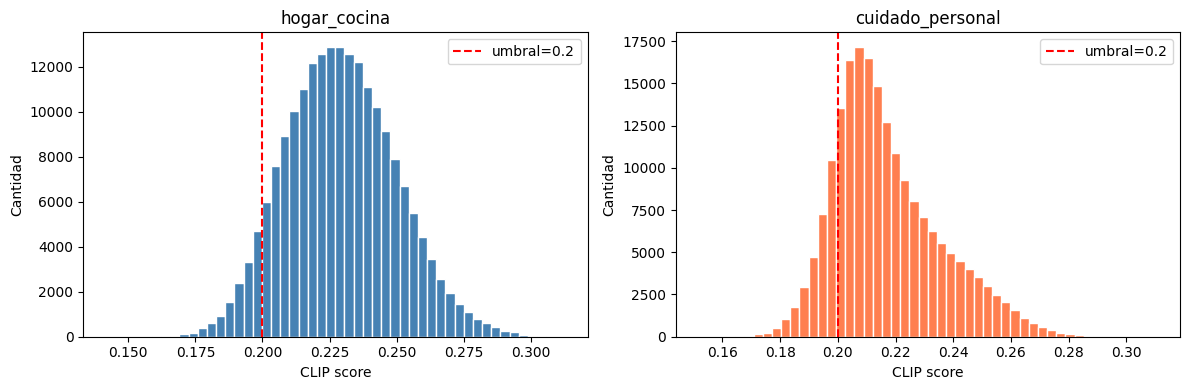

Imágenes sobre umbral por categoría:
  hogar_cocina: 186,579 disponibles, necesarias: 3,700 ✅
  cuidado_personal: 165,548 disponibles, necesarias: 3,700 ✅


In [9]:
import shutil
import matplotlib.pyplot as plt


N_TRAIN = 3000
N_VAL   = 500
N_TEST  = 200
MIN_SCORE = 0.20
# ──────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = '/content/dataset'
splits = {'train': N_TRAIN, 'val': N_VAL, 'test': N_TEST}


for split in splits:
    for cat in cats:
        os.makedirs(f'{OUTPUT_DIR}/{split}/{cat}', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, cat in enumerate(cats):
    sub = df[df['category'] == cat]['score']
    axes[i].hist(sub, bins=50, color=['steelblue', 'coral'][i], edgecolor='white')
    axes[i].axvline(MIN_SCORE, color='red', linestyle='--', label=f'umbral={MIN_SCORE}')
    axes[i].set_title(cat)
    axes[i].set_xlabel('CLIP score')
    axes[i].set_ylabel('Cantidad')
    axes[i].legend()
plt.tight_layout()
plt.savefig('/content/score_distribution.png', dpi=100)
plt.show()

print('Imágenes sobre umbral por categoría:')
for cat in cats:
    n = len(df[(df['category'] == cat) & (df['score'] >= MIN_SCORE)])
    needed = N_TRAIN + N_VAL + N_TEST
    status = '✅' if n >= needed else '⚠️  INSUFICIENTES'
    print(f'  {cat}: {n:,} disponibles, necesarias: {needed:,} {status}')

Ambas categorías superan ampliamente las 3.700 imágenes requeridas, lo que confirma que el umbral
definido es adecuado. La distribución de scores de hogar_cocina se concentra entre 0.21 y 0.26,
mientras que cuidado_personal presenta una distribución más amplia con mayor dispersión hacia valores
altos, sugiriendo que CLIP identificó con mayor variabilidad los productos de esta categoría.
En ambos casos la cantidad de imágenes disponibles es suficiente para conformar un dataset balanceado.

A continuación se construye el dataset final seleccionando las imágenes de mayor score CLIP por categoría
y distribuyéndolas aleatoriamente en las particiones de entrenamiento, validación y prueba.
Se emplea una semilla fija para garantizar la reproducibilidad de la selección.

In [10]:
import random
random.seed(42)
np.random.seed(42)

copied = {split: {cat: 0 for cat in cats} for split in splits}
errors = 0

for cat in cats:
    subset = df[(df['category'] == cat) & (df['score'] >= MIN_SCORE)]
    subset = subset.sort_values('score', ascending=False)
    paths_cat = subset['path'].tolist()

    needed = N_TRAIN + N_VAL + N_TEST
    if len(paths_cat) < needed:
        print(f'⚠️  {cat}: solo {len(paths_cat)} imgs con score>{MIN_SCORE}. '
              f'Tomando las mejores {needed} disponibles.')
        subset_all = df[df['category'] == cat].sort_values('score', ascending=False)
        paths_cat = subset_all['path'].tolist()[:needed]

    random.shuffle(paths_cat)


    split_paths = {
        'train': paths_cat[:N_TRAIN],
        'val':   paths_cat[N_TRAIN:N_TRAIN + N_VAL],
        'test':  paths_cat[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST],
    }

    for split, spaths in split_paths.items():
        for src in spaths:
            try:
                fname = pathlib.Path(src).name
                dst = f'{OUTPUT_DIR}/{split}/{cat}/{fname}'

                if os.path.exists(dst):
                    stem = pathlib.Path(fname).stem
                    ext  = pathlib.Path(fname).suffix
                    dst  = f'{OUTPUT_DIR}/{split}/{cat}/{stem}_{random.randint(1000,9999)}{ext}'
                shutil.copy2(src, dst)
                copied[split][cat] += 1
            except Exception as e:
                errors += 1


print('\n Dataset construido:')
total = 0
for split in splits:
    for cat in cats:
        n = copied[split][cat]
        total += n
        print(f'  {split}/{cat}: {n}')
print(f'\nTotal copiadas: {total:,}  |  Errores: {errors}')


📁 Dataset construido:
  train/hogar_cocina: 3000
  train/cuidado_personal: 3000
  val/hogar_cocina: 500
  val/cuidado_personal: 500
  test/hogar_cocina: 200
  test/cuidado_personal: 200

Total copiadas: 7,400  |  Errores: 0


Se genera una muestra visual del conjunto de entrenamiento para verificar que las imágenes
fueron copiadas y etiquetadas correctamente. Se muestran las primeras ocho imágenes de cada
categoría como control de calidad antes de proceder con el entrenamiento.

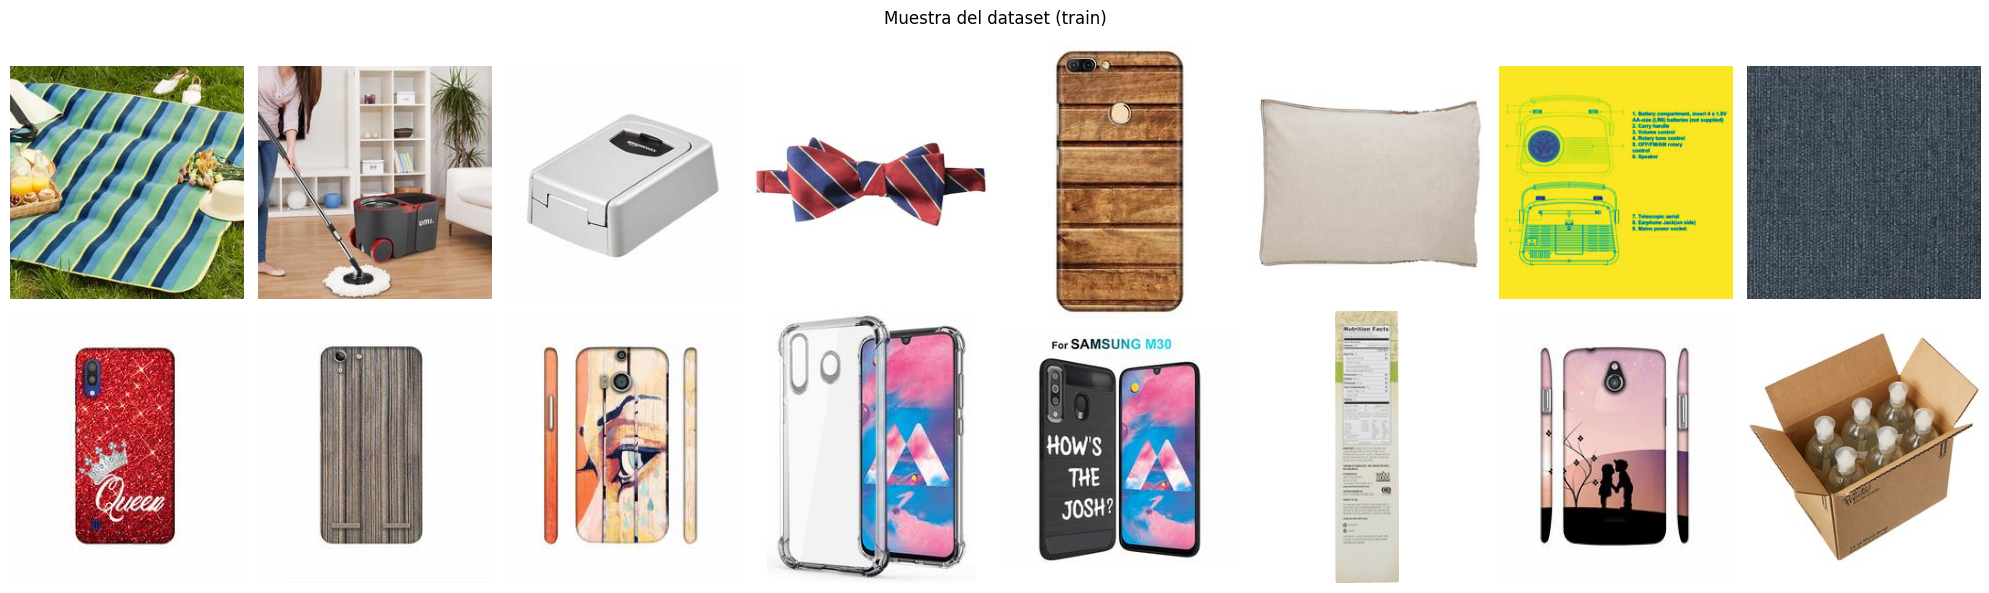

✅ Muestra guardada en /content/dataset_sample.png


In [11]:

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for row, cat in enumerate(cats):
    cat_imgs = list(pathlib.Path(f'{OUTPUT_DIR}/train/{cat}').glob('*'))[:8]
    for col, img_path in enumerate(cat_imgs):
        ax = axes[row][col]
        ax.imshow(Image.open(img_path))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cat.replace('_', '\n'), fontsize=8, rotation=90, labelpad=10)
plt.suptitle('Muestra del dataset (train)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/dataset_sample.png', dpi=100, bbox_inches='tight')
plt.show()
print(' Muestra guardada en /content/dataset_sample.png')

La muestra confirma que las imágenes fueron asignadas correctamente a cada partición. Se observa
variedad visual dentro de cada categoría, lo cual es favorable para la generalización del modelo.
No obstante, se identifican algunas imágenes con etiquetas cuestionables, como corbatas o fundas
de celular clasificadas en hogar_cocina, lo cual es atribuible al ruido inherente del etiquetado
automático con CLIP.

In [12]:
MIN_SCORE_NUEVO = 0.24

print('Con umbral 0.24:')
for cat in ['hogar_cocina', 'cuidado_personal']:
    n = len(df[(df['category'] == cat) & (df['score'] >= MIN_SCORE_NUEVO)])
    print(f'  {cat}: {n:,} disponibles (necesarias: 3,700) {"✅" if n >= 3700 else "⚠️"}')

Con umbral 0.24:
  hogar_cocina: 59,497 disponibles (necesarias: 3,700) ✅
  cuidado_personal: 25,701 disponibles (necesarias: 3,700) ✅


Se evaluó un umbral alternativo de 0.24 para verificar si una selección más estricta de imágenes
seguía garantizando la cantidad mínima requerida por categoría. Con este umbral ambas categorías
continúan superando las 3.700 imágenes necesarias, aunque la disponibilidad de cuidado_personal
se reduce considerablemente respecto a hogar_cocina, lo que refleja la mayor dispersión de scores
observada anteriormente en esa categoría.

Se reconstruye el dataset aplicando el umbral de confianza ajustado a 0.24, eliminando primero
la versión anterior para evitar mezcla de datos. Se seleccionan y distribuyen nuevamente las
imágenes en las particiones correspondientes, priorizando aquellas con mayor score CLIP.

In [13]:
import shutil, os, random, pathlib
import numpy as np

random.seed(42)
np.random.seed(42)

OUTPUT_DIR = '/content/dataset'
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print('🗑️  Dataset anterior eliminado')

cats = ['hogar_cocina', 'cuidado_personal']
splits = {'train': 3000, 'val': 500, 'test': 200}
MIN_SCORE_NUEVO = 0.24

for split in splits:
    for cat in cats:
        os.makedirs(f'{OUTPUT_DIR}/{split}/{cat}', exist_ok=True)

copied = {split: {cat: 0 for cat in cats} for split in splits}
errors = 0

for cat in cats:
    subset = df[(df['category'] == cat) & (df['score'] >= MIN_SCORE_NUEVO)]
    subset = subset.sort_values('score', ascending=False)
    paths_cat = subset['path'].tolist()

    random.shuffle(paths_cat)

    split_paths = {
        'train': paths_cat[:3000],
        'val':   paths_cat[3000:3500],
        'test':  paths_cat[3500:3700],
    }

    for split, spaths in split_paths.items():
        for src in spaths:
            try:
                fname = pathlib.Path(src).name
                dst = f'{OUTPUT_DIR}/{split}/{cat}/{fname}'
                if os.path.exists(dst):
                    stem = pathlib.Path(fname).stem
                    ext  = pathlib.Path(fname).suffix
                    dst  = f'{OUTPUT_DIR}/{split}/{cat}/{stem}_{random.randint(1000,9999)}{ext}'
                shutil.copy2(src, dst)
                copied[split][cat] += 1
            except:
                errors += 1

print(' Dataset reconstruido con umbral 0.24:')
total = 0
for split in splits:
    for cat in cats:
        n = copied[split][cat]
        total += n
        print(f'  {split}/{cat}: {n}')
print(f'\nTotal: {total:,}  |  Errores: {errors}')

🗑️  Dataset anterior eliminado
📁 Dataset reconstruido con umbral 0.24:
  train/hogar_cocina: 3000
  train/cuidado_personal: 3000
  val/hogar_cocina: 500
  val/cuidado_personal: 500
  test/hogar_cocina: 200
  test/cuidado_personal: 200

Total: 7,400  |  Errores: 0


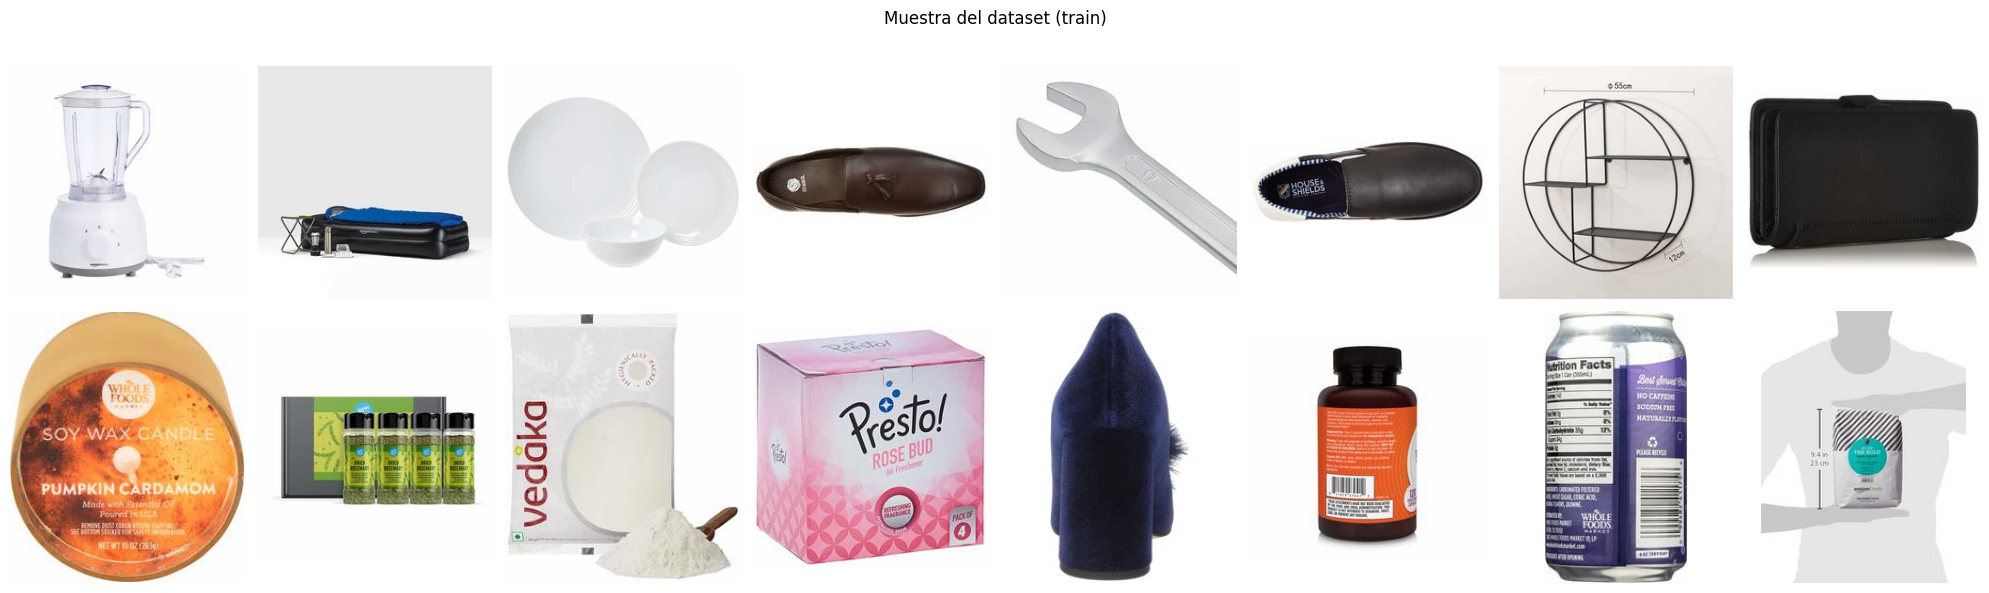

✅ Muestra guardada en /content/dataset_sample.png


In [14]:

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for row, cat in enumerate(cats):
    cat_imgs = list(pathlib.Path(f'{OUTPUT_DIR}/train/{cat}').glob('*'))[:8]
    for col, img_path in enumerate(cat_imgs):
        ax = axes[row][col]
        ax.imshow(Image.open(img_path))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cat.replace('_', '\n'), fontsize=8, rotation=90, labelpad=10)
plt.suptitle('Muestra del dataset (train)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/dataset_sample.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Muestra guardada en /content/dataset_sample.png')

Se genera nuevamente la muestra visual del conjunto de entrenamiento para verificar la calidad
del dataset reconstruido con el umbral ajustado.

Respecto a la versión anterior, se observa una
mejora notable en la coherencia de las etiquetas: hogar_cocina muestra productos claramente
identificables como licuadoras, platos y herramientas, mientras que cuidado_personal agrupa
productos de higiene, suplementos y cosméticos.

El ruido de etiquetado se redujo visiblemente
al aplicar un criterio de selección más estricto.

## Paso 4: Entrenamiento MobileNetV2

*   List item
*   List item

### Arquitectura
| Componente | Detalle |
|---|---|
| Base | MobileNetV2 + pesos ImageNet (congelada en fase 1) |
| Pooling | GlobalAveragePooling2D |
| Dense | 128 neuronas, ReLU + Dropout(0.3) |
| Salida | 2 neuronas, Softmax |
| Entrada | 224 x 224 x 3 |

Se definen los hiperparámetros del entrenamiento. Se establecen 5 épocas por fase con tasas de
aprendizaje diferenciadas: una tasa mayor para la fase inicial y una más conservadora para el
fine-tuning, con el fin de evitar la degradación de los pesos preentrenados durante el ajuste fino.

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_PH1 = 5    # Fase 1: solo head
EPOCHS_PH2 = 5    # Fase 2: fine-tuning
LR_PH1     = 1e-3
LR_PH2     = 1e-5
NUM_CLASSES = 2

CLASS_NAMES = sorted(cats)  # ['cuidado_personal', 'hogar_cocina']
print('Clases:', CLASS_NAMES)

Clases: ['cuidado_personal', 'hogar_cocina']


In [16]:
# Data generators con augmentation para train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
)

val_gen = val_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

print(f'\nClases detectadas: {train_gen.class_indices}')
print(f'Train: {train_gen.samples} imágenes')
print(f'Val:   {val_gen.samples} imágenes')

Found 6000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.

Clases detectadas: {'cuidado_personal': 0, 'hogar_cocina': 1}
Train: 6000 imágenes
Val:   1000 imágenes


Se configuran los generadores de datos para entrenamiento y validación.

Al conjunto de entrenamiento
se le aplica data augmentation con transformaciones de rotación, desplazamiento, zoom y variación
de brillo, con el fin de aumentar la variabilidad visual y reducir el sobreajuste.

El generador
de validación aplica únicamente la normalización. Se confirma la carga correcta de 6.000 imágenes
para entrenamiento y 1.000 para validación, distribuidas equitativamente entre las dos clases.

In [17]:
# Construir modelo
def build_model(trainable_base=False):
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base.trainable = trainable_base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base

model_tf, base_model = build_model(trainable_base=False)
model_tf.summary()
print(f'\nParámetros entrenables (fase 1): {model_tf.trainable_variables.__len__()}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros entrenables (fase 1): 4


Se construye el modelo sobre la base de MobileNetV2 con pesos preentrenados de ImageNet, manteniendo
la base congelada para la fase inicial.

En esta configuración solo los 164.226 parámetros de la
cabeza de clasificación son entrenables, mientras que los 2.257.984 parámetros de la base permanecen
fijos, lo que permite un entrenamiento inicial más estable y eficiente.

In [18]:
# ─── Fase 1: Entrenar solo el head ────────────────────────────────────────────
model_tf.compile(
    optimizer=optimizers.Adam(learning_rate=LR_PH1),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cb_list_ph1 = [
    callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

print('🚀 Fase 1 — Entrenando head (base congelada)...')
history_ph1 = model_tf.fit(
    train_gen,
    epochs=EPOCHS_PH1,
    validation_data=val_gen,
    callbacks=cb_list_ph1,
    verbose=1,
)

🚀 Fase 1 — Entrenando head (base congelada)...
Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 132s 592ms/step - accuracy: 0.7773 - loss: 0.4783 - val_accuracy: 0.8290 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 432ms/step - accuracy: 0.8063 - loss: 0.4108 - val_accuracy: 0.8210 - val_loss: 0.3860 - learning_rate: 0.0010
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 430ms/step - accuracy: 0.8260 - loss: 0.3819 - val_accuracy: 0.8190 - val_loss: 0.3796 - learning_rate: 0.0010
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 443ms/step - accuracy: 0.8312 - loss: 0.3609 - val_accuracy: 0.8280 - val_loss: 0.3743 - learning_rate: 0.0010
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 430ms/step - accuracy: 0.8447 - loss: 0.3460 - val_accuracy: 0.8400 - val_loss: 0.3676 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


Se ejecutó la Fase 1 del entrenamiento ajustando únicamente la cabeza de clasificación con la base
congelada. Se incorporan callbacks de early stopping y reducción de tasa de aprendizaje para
estabilizar el proceso.

Al finalizar las 5 épocas se alcanza una precisión de validación del 84%,
con una pérdida decreciente sostenida que indica que el modelo aprendió de forma consistente
sin señales de sobreajuste relevantes.

In [19]:
# ─── Fase 2: Fine-tuning últimas 30 capas ─────────────────────────────────────
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas en base: {n_trainable} de {len(base_model.layers)}')

model_tf.compile(
    optimizer=optimizers.Adam(learning_rate=LR_PH2),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cb_list_ph2 = [
    callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        '/content/productlens_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1,
    ),
]

print('🚀 Fase 2 — Fine-tuning (últimas 30 capas)...')
history_ph2 = model_tf.fit(
    train_gen,
    epochs=EPOCHS_PH2,
    validation_data=val_gen,
    callbacks=cb_list_ph2,
    verbose=1,
)

Capas descongeladas en base: 30 de 154
🚀 Fase 2 — Fine-tuning (últimas 30 capas)...
Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.7738 - loss: 0.5242
Epoch 1: val_accuracy improved from None to 0.83300, saving model to /content/productlens_best.keras

Epoch 1: finished saving model to /content/productlens_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 114s 519ms/step - accuracy: 0.7952 - loss: 0.4589 - val_accuracy: 0.8330 - val_loss: 0.3945
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8309 - loss: 0.3688
Epoch 2: val_accuracy improved from 0.83300 to 0.83900, saving model to /content/productlens_best.keras

Epoch 2: finished saving model to /content/productlens_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 437ms/step - accuracy: 0.8347 - loss: 0.3695 - val_accuracy: 0.8390 - val_loss: 0.3810
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8389 - loss: 0.3545
Epoch 3: val_accuracy improved from 0.83900 to 0.84100, saving model to /co

Se ejecutó la Fase 2 desbloqueando las últimas 30 capas de la base para especializar los pesos
preentrenados en las categorías del proyecto, utilizando una tasa de aprendizaje reducida para
evitar la degradación del conocimiento adquirido en ImageNet. Se agrega un callback de guardado
automático del mejor modelo.

Al finalizar las 5 épocas la precisión de validación alcanza 84.2%,
con mejoras progresivas época a época, lo que confirma que el fine-tuning aportó una ganancia
marginal pero consistente respecto a la fase anterior.

In [20]:
# Fase 2 extendida — 10 épocas más
print('🚀 Fase 2 extendida...')
history_ph2b = model_tf.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[
        callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            '/content/productlens_best.keras',
            save_best_only=True,
            monitor='val_accuracy',
            verbose=1,
        ),
    ],
    verbose=1,
)
print(f'Mejor val accuracy: {max(history_ph2b.history["val_accuracy"]):.4f}')

🚀 Fase 2 extendida...
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8626 - loss: 0.3062
Epoch 1: val_accuracy improved from None to 0.84400, saving model to /content/productlens_best.keras

Epoch 1: finished saving model to /content/productlens_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 86s 441ms/step - accuracy: 0.8645 - loss: 0.3023 - val_accuracy: 0.8440 - val_loss: 0.3722 - learning_rate: 1.0000e-05
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8796 - loss: 0.2809
Epoch 2: val_accuracy did not improve from 0.84400
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 433ms/step - accuracy: 0.8752 - loss: 0.2883 - val_accuracy: 0.8440 - val_loss: 0.3693 - learning_rate: 1.0000e-05
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8811 - loss: 0.2846
Epoch 3: val_accuracy did not improve from 0.84400
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 430ms/step - accuracy: 0.8745 - loss: 0.2918 - val_accuracy: 0.8400 - val_loss: 0.3695 - learning_rate: 1.0000e-05


Se ejecutó una fase de entrenamiento extendida sobre 10 épocas adicionales para explorar si el
modelo podía superar el 84.4% de precisión de validación alcanzado.

Los resultados muestran que
la precisión de entrenamiento continuó mejorando hasta 90.5%, pero la validación se mantuvo
estancada en 84.4% desde la primera época, lo que indica que el modelo alcanzó su límite de
generalización con el dataset disponible.

Este comportamiento es atribuible al ruido en las
etiquetas generadas por CLIP, no a la capacidad de la arquitectura.

## Paso 5: Evaluación y curvas de entrenamiento

Se grafican las curvas de accuracy y pérdida combinando ambas fases de entrenamiento para
obtener una visión completa del proceso. La línea vertical indica el punto de transición hacia
el fine-tuning y la línea horizontal marca la meta de 88% de precisión establecida como referencia.

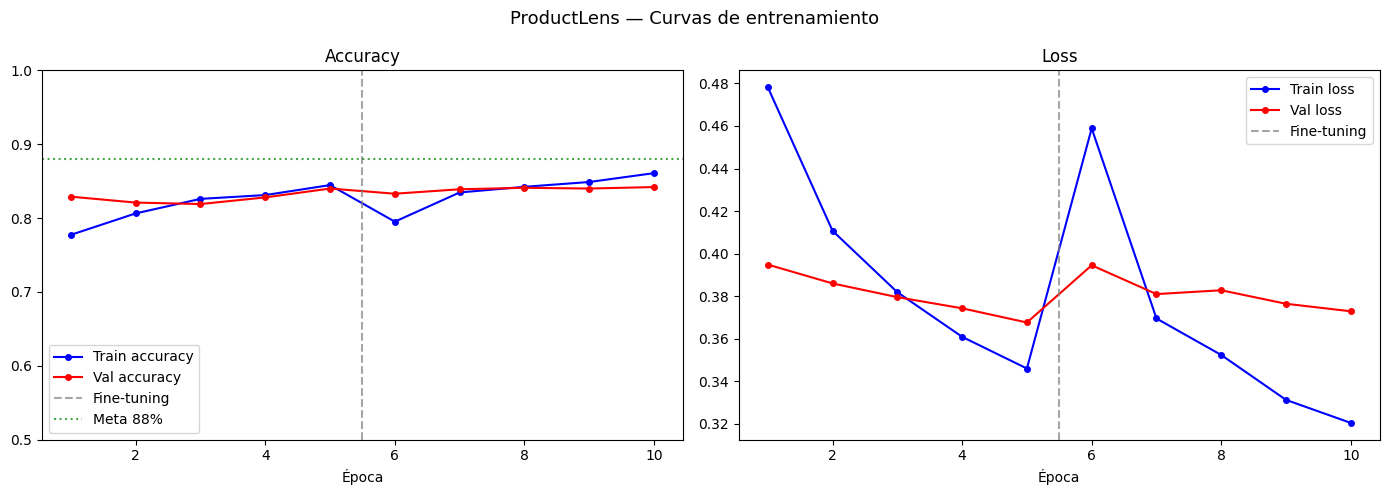

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc = history_ph1.history['accuracy'] + history_ph2.history['accuracy']
val_acc = history_ph1.history['val_accuracy'] + history_ph2.history['val_accuracy']
loss = history_ph1.history['loss'] + history_ph2.history['loss']
val_loss = history_ph1.history['val_loss'] + history_ph2.history['val_loss']
epochs_total = range(1, len(acc) + 1)
split_ep = len(history_ph1.history['accuracy'])  # donde empieza fase 2

axes[0].plot(epochs_total, acc, 'b-o', label='Train accuracy', markersize=4)
axes[0].plot(epochs_total, val_acc, 'r-o', label='Val accuracy', markersize=4)
axes[0].axvline(split_ep + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning')
axes[0].axhline(0.88, color='green', linestyle=':', alpha=0.7, label='Meta 88%')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])

axes[1].plot(epochs_total, loss, 'b-o', label='Train loss', markersize=4)
axes[1].plot(epochs_total, val_loss, 'r-o', label='Val loss', markersize=4)
axes[1].axvline(split_ep + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning')
axes[1].set_title('Loss')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.suptitle('ProductLens — Curvas de entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

Las curvas muestran un entrenamiento estable en ambas fases. La precisión de validación se mantiene
cercana a la de entrenamiento a lo largo de todas las épocas, lo que indica ausencia de sobreajuste.

El pico de pérdida observado al inicio del fine-tuning es esperado, ya que al descongelar capas
el modelo requiere una época de readaptación antes de estabilizarse. La meta del 88% no fue
alcanzada, resultado consistente con el ruido introducido por el etiquetado automático con CLIP.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluación sobre el conjunto de test
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

print('Evaluando sobre test set...')
test_loss, test_acc = model_tf.evaluate(test_gen, verbose=0)
print(f'\n📊 Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'📊 Test loss:     {test_loss:.4f}')

if test_acc >= 0.88:
    print('Meta del 88% alcanzada!')
else:
    print(f'Por debajo de la meta. Considera más épocas o ajustar augmentation.')

Found 400 images belonging to 2 classes.
Evaluando sobre test set...

📊 Test accuracy: 0.8450 (84.50%)
📊 Test loss:     0.3331
⚠️  Por debajo de la meta. Considera más épocas o ajustar augmentation.


Se evalúa el modelo sobre el conjunto de prueba, que no fue utilizado durante el entrenamiento
ni la validación. Se obtiene una precisión final de 84.5%, resultado coherente con lo observado
en las curvas de entrenamiento.

Si bien no se alcanzó la meta del 88%, el resultado es satisfactorio
considerando que las etiquetas fueron generadas de forma automática mediante CLIP sin supervisión manual.

##Matriz de confusión


Reporte de clasificación:
                  precision    recall  f1-score   support

cuidado_personal       0.84      0.84      0.84       200
    hogar_cocina       0.84      0.84      0.84       200

        accuracy                           0.84       400
       macro avg       0.84      0.84      0.84       400
    weighted avg       0.84      0.84      0.84       400



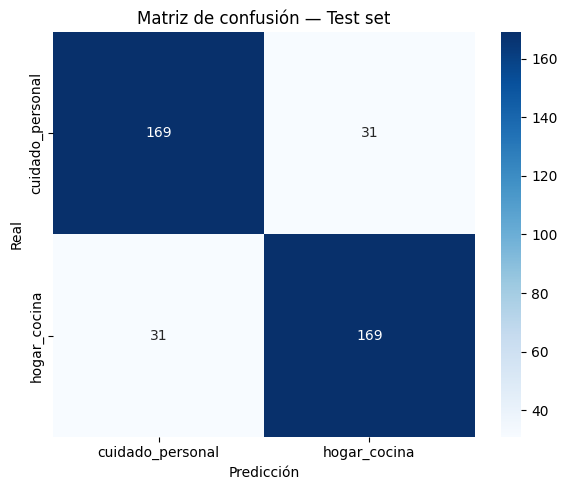

In [23]:

y_pred_probs = model_tf.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print('\nReporte de clasificación:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — Test set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120)
plt.show()

Se genera el reporte de clasificación y la matriz de confusión sobre el conjunto de prueba.
El modelo alcanza precisión, recall y f1-score de 0.84 en ambas categorías, lo que indica un
comportamiento equilibrado sin sesgo hacia ninguna clase.

La matriz de confusión muestra 169
aciertos por categoría y 31 errores en cada caso, confirmando que las confusiones se distribuyen
de forma simétrica entre las dos clases.

## Visualización de predicciones incorrectas (top 8)


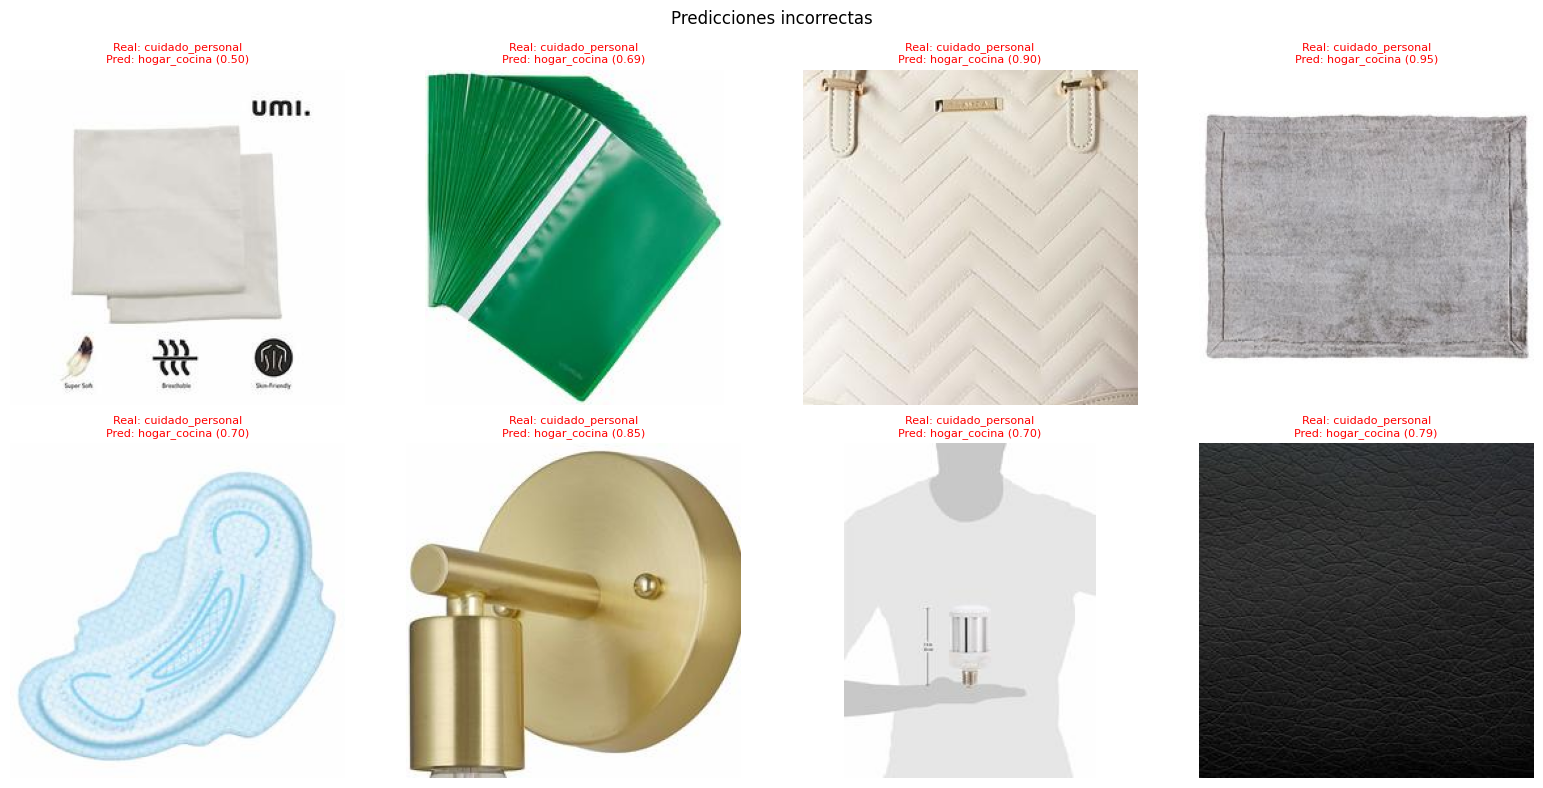

In [24]:
wrong_idx = np.where(y_pred != y_true)[0][:8]
if len(wrong_idx) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    test_paths = [test_gen.filepaths[i] for i in wrong_idx]
    for ax, path, idx in zip(axes.flat, test_paths, wrong_idx):
        img = Image.open(path)
        ax.imshow(img)
        conf = float(y_pred_probs[idx].max())
        ax.set_title(
            f'Real: {class_names[y_true[idx]]}\n'
            f'Pred: {class_names[y_pred[idx]]} ({conf:.2f})',
            fontsize=8, color='red'
        )
        ax.axis('off')
    plt.suptitle('Predicciones incorrectas', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/wrong_predictions.png', dpi=100)
    plt.show()
else:
    print('🎉 ¡Sin predicciones incorrectas en la muestra!')

Se visualizan algunas de las predicciones incorrectas del modelo para analizar cualitativamente
los errores cometidos.

Se observa que la mayoría corresponde a productos de cuidado_personal
clasificados como hogar_cocina, y en varios casos con alta confianza. Los productos mal clasificados
presentan características visuales ambiguas: telas, superficies lisas o fondos neutros que el
modelo asocia con artículos del hogar, lo cual es un error esperable dado el ruido en las etiquetas
del dataset original.

## Paso 6: Guardar el modelo

Se guarda el modelo entrenado en formato nativo de Keras junto con el mapeo de clases en un
archivo JSON. Este par de archivos constituye el artefacto principal que será consumido por
el backend de la aplicación para realizar inferencias.

In [26]:
MODEL_KERAS_PATH = '/content/productlens_model.keras'
model_tf.save(MODEL_KERAS_PATH)
print(f' Modelo guardado: {MODEL_KERAS_PATH}')

import json
class_map = {v: k for k, v in test_gen.class_indices.items()}
with open('/content/class_map.json', 'w') as f:
    json.dump(class_map, f, indent=2, ensure_ascii=False)
print(f' Mapeo de clases: {class_map}')

✅ Modelo guardado: /content/productlens_model.keras
✅ Mapeo de clases: {0: 'cuidado_personal', 1: 'hogar_cocina'}


In [27]:
import shutil

os.makedirs('/content/productlens_output', exist_ok=True)
shutil.copy(MODEL_KERAS_PATH, '/content/productlens_output/')
shutil.copy('/content/class_map.json', '/content/productlens_output/')
shutil.copy('/content/training_curves.png', '/content/productlens_output/')
shutil.copy('/content/confusion_matrix.png', '/content/productlens_output/')
shutil.copy('/content/dataset_sample.png', '/content/productlens_output/')

shutil.make_archive('/content/productlens_output', 'zip', '/content/productlens_output')
print('\n Paquete listo para descargar: /content/productlens_output.zip')
print('   Contiene:')
for f in os.listdir('/content/productlens_output'):
    size = os.path.getsize(f'/content/productlens_output/{f}') / 1e6
    print(f'   - {f}  ({size:.1f} MB)')


✅ Paquete listo para descargar: /content/productlens_output.zip
   Contiene:
   - training_curves.png  (0.1 MB)
   - dataset_sample.png  (0.7 MB)
   - confusion_matrix.png  (0.0 MB)
   - productlens_model.keras  (23.8 MB)
   - class_map.json  (0.0 MB)


## Extra: Probar el modelo con una imagen nueva

Se verifica la integridad del conjunto de prueba confirmando la disponibilidad de las 400 imágenes
esperadas, y se selecciona una imagen aleatoria para realizar una predicción de ejemplo que
valide el funcionamiento del pipeline de inferencia de extremo a extremo.

In [29]:
print(class_map)

{0: 'cuidado_personal', 1: 'hogar_cocina'}


In [32]:
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'¿Existe el directorio test?: {pathlib.Path(f"{OUTPUT_DIR}/test").exists()}')
print(f'Archivos encontrados: {len(sample_path)}')

OUTPUT_DIR: /content/dataset
¿Existe el directorio test?: True
Archivos encontrados: 400


In [33]:
test_img = str(random.choice(sample_path))
print(f'Imagen seleccionada: {test_img}')

Imagen seleccionada: /content/dataset/test/hogar_cocina/b800166d.jpg


Se ejecuta la función de predicción sobre la imagen seleccionada y se visualiza el resultado
junto con la categoría asignada y el porcentaje de confianza.

Imagen: /content/dataset/test/hogar_cocina/b800166d.jpg
Categoría predicha: cuidado_personal
Confianza: 69.2%
Top 3: [('cuidado_personal', 0.6916322112083435), ('hogar_cocina', 0.3083677887916565)]


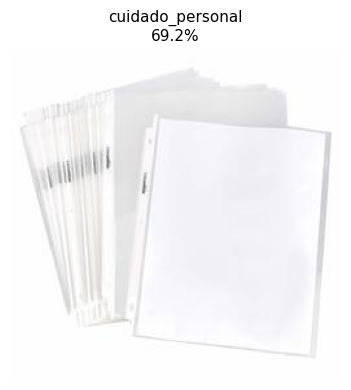

In [34]:
result = predict_image(test_img, model_tf, class_map)
print(f'Imagen: {test_img}')
print(f'Categoría predicha: {result["categoria"]}')
print(f'Confianza: {result["confianza"]*100:.1f}%')
print(f'Top 3: {result["top3"]}')

plt.figure(figsize=(4, 4))
plt.imshow(Image.open(test_img))
plt.title(f"{result['categoria']}\n{result['confianza']*100:.1f}%", fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

La predicción sobre la imagen de prueba resultó incorrecta: la imagen pertenece a hogar_cocina
pero fue clasificada como cuidado_personal con una confianza relativamente baja de 69.2%, lo
que refleja la incertidumbre del modelo ante productos visualmente ambiguos. Este tipo de error
es consistente con los 31 casos incorrectos identificados en la matriz de confusión.

Saving image_prof.png to image_prof.png
Categoría predicha: cuidado_personal
Confianza: 98.9%
Top 3:
  cuidado_personal               98.9%  ███████████████████
  hogar_cocina                   1.1%  


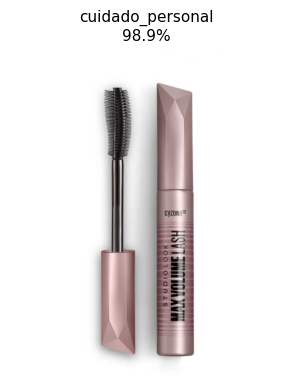

In [35]:
from google.colab import files
from PIL import Image
import numpy as np

# Subir imagen desde tu PC
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predecir
result = predict_image(img_path, model_tf, class_map)

# Mostrar resultado
print(f'Categoría predicha: {result["categoria"]}')
print(f'Confianza: {result["confianza"]*100:.1f}%')
print(f'Top 3:')
for cat, conf in result["top3"]:
    bar = '█' * int(conf * 20)
    print(f'  {cat:<30} {conf*100:.1f}%  {bar}')

# Mostrar imagen
plt.figure(figsize=(4, 4))
plt.imshow(Image.open(img_path))
plt.title(f"{result['categoria']}\n{result['confianza']*100:.1f}%", fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

Se prueba el pipeline de inferencia con una imagen externa cargada directamente desde el equipo
local, simulando el flujo de uso real de la aplicación. El modelo clasificó correctamente una
imagen de máscara de pestañas como cuidado_personal con una confianza de 98.9%, resultado que
demuestra un rendimiento sólido del modelo ante imágenes de tipo e-commerce con fondo limpio.

Saving WhatsApp Image 2026-05-16 at 8.41.02 PM.jpeg to WhatsApp Image 2026-05-16 at 8.41.02 PM.jpeg
Categoría predicha: hogar_cocina
Confianza: 100.0%
Top 3:
  hogar_cocina                   100.0%  ███████████████████
  cuidado_personal               0.0%  


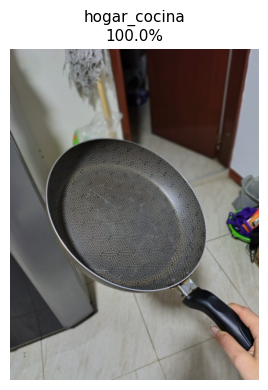

In [36]:
from google.colab import files
from PIL import Image
import numpy as np

# Subir imagen desde tu PC
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predecir
result = predict_image(img_path, model_tf, class_map)

# Mostrar resultado
print(f'Categoría predicha: {result["categoria"]}')
print(f'Confianza: {result["confianza"]*100:.1f}%')
print(f'Top 3:')
for cat, conf in result["top3"]:
    bar = '█' * int(conf * 20)
    print(f'  {cat:<30} {conf*100:.1f}%  {bar}')

# Mostrar imagen
plt.figure(figsize=(4, 4))
plt.imshow(Image.open(img_path))
plt.title(f"{result['categoria']}\n{result['confianza']*100:.1f}%", fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

Se realiza una segunda prueba con una fotografía casual tomada desde un dispositivo móvil,
con fondo real y condiciones de iluminación no controladas. El modelo clasificó correctamente
el sartén como hogar_cocina con una confianza del 100%, lo que evidencia que el modelo
generaliza adecuadamente más allá de imágenes de tipo e-commerce.

finalmente se recopilaron todos los artefactos generados durante el pipeline en un directorio unificado y se
comprimen en un archivo ZIP para su descarga. El paquete resultante contiene el modelo entrenado, el mapeo de clases y las visualizaciones de evaluación.

In [37]:
from google.colab import files
files.download('/content/productlens_output.zip')
print('📦 Descarga iniciada')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Descarga iniciada
